# 02 · Demo: Predicting Appointment No-Shows

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/monfurkat-glitch/HealthProject/blob/main/notebooks/02_demo.ipynb)

**Project:** MED-01 Hospital Appointment No-Show Prediction · **Author:** Furkat Toshmatov

This notebook runs the finished system end to end: **raw appointment details → validation → features → saved model → no-show probability, risk band, and explanation.**

**How to run:** in Google Colab choose **Runtime → Run all** (about 1–2 minutes). It downloads the project from GitHub, so no files need to be uploaded. It also runs locally from a clone of the repository.

> The model is **decision support**: it helps clinic staff decide whom to remind or call. It never cancels, rebooks, or refuses care.

## 1. Setup

In [1]:
import os, subprocess, sys
from pathlib import Path

REPO_URL = "https://github.com/monfurkat-glitch/HealthProject.git"
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB and not Path("HealthProject").exists():
    subprocess.run(["git", "clone", "--depth", "1", REPO_URL], check=True)
# Work from the repository root (Colab: ./HealthProject, local: the parent of notebooks/)
for candidate in [Path("HealthProject"), Path(".."), Path(".")]:
    if (candidate / "src" / "predict.py").exists():
        os.chdir(candidate)
        break
sys.path.insert(0, os.getcwd())
print("Working directory:", os.getcwd())

# The model was saved with scikit-learn 1.7.2; install the same version if needed (quick, no restart required)
import importlib.metadata as md
if md.version("scikit-learn") != "1.7.2":
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "scikit-learn==1.7.2"], check=True)
print("scikit-learn", md.version("scikit-learn"))

Working directory: D:\AIML-Project-Health\HealthProject
scikit-learn 1.7.2


## 2. Load the saved model

In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.predict import NoShowPredictor, InvalidAppointment, load_history

predictor = NoShowPredictor()
info = predictor.info
print("Model:            logistic regression", info["params"])
print("Trained on:       ", info["trained_on"], f"({info['training_rows']:,} appointments)")
print("Risk-band cut-offs: Low < {:.3f} <= Medium < {:.3f} <= High".format(*info["band_cutoffs"]))
print("Features:         ", ", ".join(info["features"]))
if predictor.version_warning:
    print("WARNING:", predictor.version_warning)

Model:            logistic regression {'C': 1.0}
Trained on:        2016-04-29 to 2016-06-02 (92,845 appointments)
Risk-band cut-offs: Low < 0.233 <= Medium < 0.323 <= High
Features:          age, lead_days, prior_appointments, prior_no_shows, prior_no_show_rate, male, scholarship, hypertension, diabetes, alcoholism, disability, same_day, neighbourhood, appointment_weekday


## 3. Score one appointment

Change the values in the form (Colab shows them as input boxes) and run the cell again.
Only information known **at booking time** is used.

In [3]:
age = 19  #@param {type:"integer"}
gender = "F"  #@param ["F", "M"]
neighbourhood = "JARDIM CAMBURI"  #@param {type:"string"}
scholarship = True  #@param {type:"boolean"}
hypertension = False  #@param {type:"boolean"}
diabetes = False  #@param {type:"boolean"}
alcoholism = False  #@param {type:"boolean"}
handicap = 0  #@param {type:"integer"}
scheduled_day = "2016-06-01"  #@param {type:"date"}
appointment_day = "2016-06-29"  #@param {type:"date"}
prior_appointments = 0  #@param {type:"integer"}
prior_no_shows = 0  #@param {type:"integer"}

appointment = dict(age=age, gender=gender, neighbourhood=neighbourhood, scholarship=scholarship,
                   hypertension=hypertension, diabetes=diabetes, alcoholism=alcoholism, handicap=handicap,
                   scheduled_day=scheduled_day, appointment_day=appointment_day,
                   prior_appointments=prior_appointments, prior_no_shows=prior_no_shows)
try:
    result = predictor.predict(appointment)
    print(f"No-show probability: {result['no_show_probability']:.1%}")
    print(f"Risk band:           {result['risk_band']}")
    print("Main factors:        " + "; ".join(result["main_factors"]))
    for w in result["warnings"]:
        print("Warning:            ", w)
except InvalidAppointment as e:
    print("Cannot score this appointment:")
    for err in e.errors:
        print(" -", err)

No-show probability: 35.1%
Risk band:           High
Main factors:        not booked for the same day raises risk; welfare (Scholarship) raises risk; age 19 raises risk


## 4. Score a day's appointments and rank them

Staff would receive a list like this, sorted by risk, and follow up the **High** band first.

In [4]:
day_list = [
    {"patient_id": "A", "age": 62, "gender": "M", "neighbourhood": "JARDIM DA PENHA", "hypertension": 1,
     "diabetes": 1, "scheduled_day": "2016-06-06", "appointment_day": "2016-06-06"},
    {"patient_id": "B", "age": 34, "gender": "F", "neighbourhood": "CENTRO",
     "scheduled_day": "2016-06-01", "appointment_day": "2016-06-10"},
    {"patient_id": "C", "age": 15, "gender": "F", "neighbourhood": "ITARARÉ", "scholarship": 1,
     "scheduled_day": "2016-05-02", "appointment_day": "2016-06-20", "prior_appointments": 3, "prior_no_shows": 2},
    {"patient_id": "D", "age": 8, "gender": "M", "neighbourhood": "MARUÍPE",
     "scheduled_day": "2016-05-20", "appointment_day": "2016-06-20"},
    {"patient_id": "E", "age": 45, "gender": "F", "neighbourhood": "SANTA MARTHA", "scholarship": 1,
     "scheduled_day": "2016-06-15", "appointment_day": "2016-06-17", "prior_appointments": 5, "prior_no_shows": 0},
    {"patient_id": "F", "age": 78, "gender": "F", "neighbourhood": "BONFIM", "hypertension": 1,
     "scheduled_day": "2016-06-13", "appointment_day": "2016-06-20"},
]
results = predictor.predict(day_list)
table = pd.DataFrame([{"patient": a["patient_id"], "age": a["age"], "lead_days": r["lead_days"],
                       "probability": r["no_show_probability"], "risk_band": r["risk_band"],
                       "main_factors": "; ".join(r["main_factors"])} for a, r in zip(day_list, results)])
table = table.sort_values("probability", ascending=False).reset_index(drop=True)
pd.set_option("display.max_colwidth", 120)
table

,patient,age,lead_days,probability,risk_band,main_factors
0,C,15,49,0.7194,High,2 earlier no-shows raises risk; not booked for the same day raises risk; neighbourhood Itararé raises risk
1,D,8,31,0.3830,High,not booked for the same day raises risk; age 8 raises risk; booked 31 days ahead raises risk
2,B,34,9,0.3066,Medium,not booked for the same day raises risk; neighbourhood Centro raises risk; appointment on a Friday lowers risk
3,F,78,7,0.2091,Low,not booked for the same day raises risk; age 78 lowers risk; neighbourhood Bonfim raises risk
4,E,45,2,0.1967,Low,not booked for the same day raises risk; 5 earlier appointments lowers risk; welfare (Scholarship) raises risk
5,A,62,0,0.0294,Low,booked for the same day lowers risk; age 62 lowers risk; neighbourhood Jardim Da Penha lowers risk


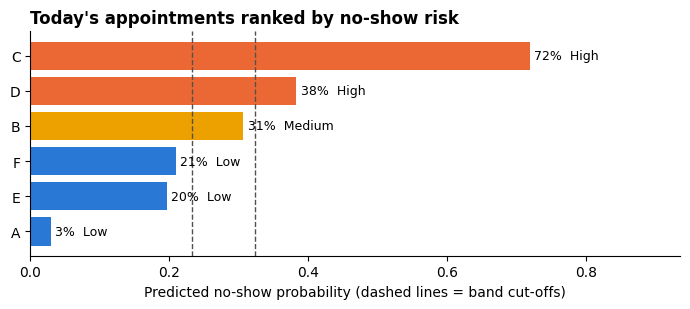

In [5]:
colors = {"High": "#eb6834", "Medium": "#eda100", "Low": "#2a78d6"}
fig, ax = plt.subplots(figsize=(7, 3.2))
bars = ax.barh(table["patient"], table["probability"], color=[colors[b] for b in table["risk_band"]])
ax.bar_label(bars, labels=[f"{p:.0%}  {b}" for p, b in zip(table["probability"], table["risk_band"])], padding=3, fontsize=9)
for cut in predictor.cutoffs:
    ax.axvline(cut, color="#52514e", ls="--", lw=1)
ax.invert_yaxis(); ax.set_xlim(0, max(table["probability"].max() * 1.3, 0.5))
ax.set_xlabel("Predicted no-show probability (dashed lines = band cut-offs)")
ax.set_title("Today's appointments ranked by no-show risk", loc="left", fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

## 5. Invalid and unusual inputs

Invalid inputs are **rejected with every problem listed**, so nothing crashes and no nonsense prediction is made.
Unusual but valid inputs are **scored with a warning**.

In [6]:
bad = {"age": -4, "gender": "X", "neighbourhood": "NOWHERE", "diabetes": "maybe",
       "scheduled_day": "2016-06-10", "appointment_day": "2016-06-01"}
try:
    predictor.predict(bad)
except InvalidAppointment as e:
    print("Rejected:")
    for err in e.errors:
        print(" -", err)

Rejected:
 - 'age' must be between 0 and 115, got -4
 - 'gender' must be F or M, got 'X'
 - 'appointment_day' (2016-06-01) is before 'scheduled_day' (2016-06-10): an appointment cannot be booked after it happens
 - 'diabetes' must be 0 or 1 (or yes/no), got 'maybe'


In [7]:
unusual = {"age": 104, "gender": "M", "neighbourhood": "ATLANTIS",
           "scheduled_day": "2016-01-04", "appointment_day": "2016-09-04"}
r = predictor.predict(unusual)
print(f"Scored anyway: {r['no_show_probability']:.1%} ({r['risk_band']})")
for w in r["warnings"]:
    print(" warning:", w)

Scored anyway: 63.8% (High)


## 6. Looking up a patient's history

In a clinic, the system would look up the patient's past appointments. Here the dataset plays that role.
Only appointments dated **before the booking day** are counted, because only their outcome was known when the appointment was booked (no leakage).

In [8]:
history = load_history()
with_history = NoShowPredictor(history=history)
counts = history.groupby("patient_id")["no_show"].agg(["size", "sum"])
patient = counts[(counts["size"] == 8) & (counts["sum"] == 4)].index.sort_values()[0]   # a patient who often misses
visits = history[history["patient_id"] == patient].sort_values("appointment_day")
print(f"Patient {patient}: {len(visits)} appointments, {visits['no_show'].sum()} no-shows, "
      f"{visits['appointment_day'].min().date()} to {visits['appointment_day'].max().date()}")

print(visits.assign(appointment_day=visits["appointment_day"].dt.date).to_string(index=False))
print()
for booking_day in ["2016-05-10", "2016-05-25", "2016-06-02"]:
    # Only the history is real; the other details are example values
    r = with_history.predict({"patient_id": patient, "age": 38, "gender": "M", "neighbourhood": "CENTRO",
                              "scheduled_day": booking_day, "appointment_day": "2016-06-10"})
    print(f"booked {booking_day}: known history = {r['prior_appointments']:>2} appointments, "
          f"{r['prior_no_shows']} no-shows -> {r['no_show_probability']:.1%} ({r['risk_band']})")

Patient 151663996687767: 8 appointments, 4 no-shows, 2016-05-03 to 2016-06-03
     patient_id appointment_day  no_show
151663996687767      2016-05-03        0
151663996687767      2016-05-09        0
151663996687767      2016-05-16        1
151663996687767      2016-05-24        1
151663996687767      2016-05-24        1
151663996687767      2016-05-30        0
151663996687767      2016-05-31        1
151663996687767      2016-06-03        0

booked 2016-05-10: known history =  2 appointments, 0 no-shows -> 30.5% (Medium)


booked 2016-05-25: known history =  5 appointments, 3 no-shows -> 58.3% (High)
booked 2016-06-02: known history =  7 appointments, 4 no-shows -> 65.9% (High)


The later the booking, the more of this patient's past appointments (and missed ones) are known, and the risk rises accordingly. Appointments on or after the booking day are never counted.

## 7. Reproducibility: retrain from the raw CSV and compare

The saved model can be rebuilt from scratch with the code in `src/`: load the CSV, clean it, create features, split by date, and refit on train + validation.
If the retrained model gives the same predictions, the saved model is exactly what the code produces.

In [9]:
from src.preprocess import build_dataset, time_split, TARGET
from src.train import logistic

data = build_dataset()
train, val, test = time_split(data)
fit = pd.concat([train, val], ignore_index=True)
retrained = logistic(False, C=1.0).fit(fit[predictor.features], fit[TARGET])

p_saved = predictor.model.predict_proba(test[predictor.features])[:, 1]
p_new = retrained.predict_proba(test[predictor.features])[:, 1]
print(f"Largest difference between saved and retrained model on {len(test):,} test appointments: {np.abs(p_saved - p_new).max():.2e}")

Largest difference between saved and retrained model on 17,676 test appointments: 0.00e+00


## 8. Reproduce the reported test results

The test period (appointments 2016-06-03 to 06-08) was used once to evaluate the final model. Scoring it again with the saved model must give the numbers in `reports/test_results.md`.

In [10]:
from src.evaluate import evaluate
from src.final import band_table, risk_band

metrics = evaluate(test[TARGET], p_saved)
print(pd.Series(metrics).round(4).to_string())
reported = json.loads(Path("reports/test_results.json").read_text())["metrics"]["final_logreg"]
print("\nMatches reports/test_results.json:", all(abs(metrics[k] - reported[k]) < 1e-4 for k in reported))
band_table(test[TARGET], risk_band(p_saved, predictor.cutoffs)).round(3)

roc_auc            0.7232
pr_auc             0.3283
precision_top20    0.3349
recall_top20       0.3623
brier              0.1376
no_show_rate       0.1849

Matches reports/test_results.json: True


,appointments,no_shows,share_of_appointments,no_show_rate,share_of_all_no_shows
band,,,,,
Low,8776,710,0.496,0.081,0.217
Medium,4910,1234,0.278,0.251,0.378
High,3990,1324,0.226,0.332,0.405


## 9. Run the automated tests

In [11]:
try:
    import pytest  # noqa: F401
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "pytest==8.4.2"], check=True)
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "--color=no"], capture_output=True, text=True)
print(result.stdout[-600:] if result.returncode == 0 else result.stdout + result.stderr)

.......................................................                  [100%]
55 passed in 11.01s



## Summary

- The saved model scores new appointments from raw details in one call, with validation, risk bands, and explanations.
- Invalid inputs are rejected clearly; unusual inputs are scored with warnings.
- Patient history is used without leakage.
- The model can be rebuilt from the raw CSV, and it reproduces the reported test results.

**Limitations** (details in the README and `reports/error_analysis.md`): ROC-AUC 0.72 on the test period; the model mainly uses lead time; welfare patients and children receive more false alarms, and elderly no-shows are rarely flagged. Use it only for supportive follow-up, never to restrict access to care.